# 2.5D U-Net for Multiple Sclerosis Lesion Segmentation

## Introduction

In this project, I implemented a **2.5D U-Net** model for automatic segmentation of
Multiple Sclerosis (MS) lesions from brain MRI scans. The dataset I used is the
**MSLesSeg** dataset (Guarnera et al., *Scientific Data*, 2025), which contains 115
FLAIR MRI scans from 75 patients.

The goal is to develop an alternative lesion segmentation algorithm and compare it
against the baseline method reported in the original paper.

**Key design decisions I made:**
- I chose a **2.5D approach** instead of full 3D to fit within Google Colab's free tier
  memory constraints (~12 GB RAM, ~15 GB GPU on a T4).
- The model is intentionally kept **small and simple**
- The training and test sets are **completely separate patient groups** as provided by
  the dataset, ensuring a fair evaluation with no data leakage.

## Background

Multiple Sclerosis (MS) is a chronic inflammatory disorder that leads to demyelination
of the central nervous system. MRI is widely used to detect MS lesions, with **FLAIR**
(Fluid Attenuated Inversion Recovery) images being particularly effective MS lesions
appear hyperintense and are generally well differentiated from surrounding tissue.

Accurate and automatic segmentation of these lesions is important for diagnosis,
monitoring disease progression, and evaluating treatment response.

## Approaches that I tried

MRI scans are inherently 3D volumes. There are three main approaches to process them:

| Approach | Description | Pros | Cons |
|----------|-------------|------|------|
| **2D** | Process one slice at a time | Very lightweight | Loses inter-slice context |
| **3D** | Use 3D convolutions on the full volume | Best spatial context | Very memory-hungry |
| **2.5D** | Stack adjacent slices as input channels | Good balance of context and efficiency | Slightly less context than 3D |

I chose **2.5D** because:
1. **Memory**: Full 3D U-Nets require significantly more GPU memory than what is available
   on free Google Colab (~15 GB on a T4 GPU).
2. **Context**: Unlike pure 2D, the model can see neighboring slices, which helps it
   understand the 3D extent of lesions and improves continuity across slices.
3. **Simplicity**: The architecture uses standard 2D convolutions, making it much easier
   to implement, debug, and understand.

In my implementation, I stack **3 adjacent axial FLAIR slices** similar
to RGB channels in a natural image. The model outputs a binary segmentation mask for the
**central slice** only.

## Setup

First, I install the required libraries and import everything needed.

In [ ]:
!pip install -q nibabel nilearn tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 45.7 MB/s eta 0:00:00


In [ ]:
import os
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from skimage.transform import resize as sk_resize

# Set random seeds for reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# Use GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    gpu_mem = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"GPU: {gpu_name}, Memory: {gpu_mem:.1f} GB")
else:
    print("WARNING: No GPU detected")

Using device: cuda
GPU: Tesla T4, Memory: 15.6 GB


## Dataset: MSLesSeg

I use the **MSLesSeg** dataset stored on my Google Drive. It contains:
- **Training set**: 93 FLAIR MRI scans organized by patient and timepoint
  (`train/P{id}/T{tp}/P{id}_T{tp}_FLAIR.nii.gz`)
- **Test set**: 22 scans organized by patient only
  (`test/P{id}/P{id}_FLAIR.nii.gz`)

Each scan has a corresponding binary lesion mask (`_MASK.nii.gz`).


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Path to the MSLesSeg dataset on Google Drive
DATA_ROOT = Path('/content/drive/MyDrive/MSLesSeg/MSLesSeg Dataset')

# Create output directory for saving models and figures
OUTPUT_DIR = DATA_ROOT / 'outputs'
OUTPUT_DIR.mkdir(exist_ok=True)

print(f"Data root: {DATA_ROOT}")
print(f"Output dir: {OUTPUT_DIR}")

# Quick check: list a few patients in train and test
print("\nTraining patients (first 3):")
train_dir = DATA_ROOT / 'train'
for p in sorted(train_dir.iterdir())[:3]:
    if p.is_dir():
        print(f"  {p.name}/")

print("\nTest patients (first 3):")
test_dir = DATA_ROOT / 'test'
for p in sorted(test_dir.iterdir())[:3]:
    if p.is_dir():
        print(f"  {p.name}/")

Mounted at /content/drive
Data root: /content/drive/MyDrive/MSLesSeg/MSLesSeg Dataset
Output dir: /content/drive/MyDrive/MSLesSeg/MSLesSeg Dataset/outputs

Training patients (first 3):
  P1/
  P10/
  P11/

Test patients (first 3):
  P54/
  P55/
  P56/


## Model Architecture

My 2.5D U-Net follows the classic encoder-decoder design with skip connections:

- **Input**: 3 adjacent FLAIR slices stacked as channels → shape `(B, 3, H, W)`
- **Encoder** (4 levels): Extracts features at progressively lower resolutions.
  Each level has two 3×3 convolutions + BatchNorm + ReLU, followed by max-pooling.
- **Bottleneck**: The deepest layer capturing the most abstract features.
- **Decoder** (4 levels): Upsamples back to original resolution. Skip connections
  from the encoder preserve fine spatial details.
- **Output**: A 1×1 convolution followed by sigmoid → shape `(B, 1, H, W)`
  (binary: lesion probability per pixel).



In [ ]:
# =============================================
# 2.5D U-Net Model
# =============================================

class DoubleConv(nn.Module):
    """Two 3x3 convolution layers, each followed by BatchNorm and ReLU."""

    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.layers(x)


class UNet25D(nn.Module):
    """
    2.5D U-Net for binary lesion segmentation.

    Takes 3 adjacent FLAIR slices as input channels and predicts
    a binary lesion mask for the central slice.
    """

    def __init__(self, in_channels=3, base_features=32):
        super().__init__()
        bf = base_features

        # Encoder (downsampling path)
        self.enc1 = DoubleConv(in_channels, bf)        # 32
        self.enc2 = DoubleConv(bf, bf * 2)              # 64
        self.enc3 = DoubleConv(bf * 2, bf * 4)          # 128
        self.enc4 = DoubleConv(bf * 4, bf * 8)          # 256
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # Bottleneck
        self.bottleneck = DoubleConv(bf * 8, bf * 16)   # 512

        # Decoder (upsampling path)
        self.up4 = nn.ConvTranspose2d(bf * 16, bf * 8, kernel_size=2, stride=2)
        self.dec4 = DoubleConv(bf * 16, bf * 8)

        self.up3 = nn.ConvTranspose2d(bf * 8, bf * 4, kernel_size=2, stride=2)
        self.dec3 = DoubleConv(bf * 8, bf * 4)

        self.up2 = nn.ConvTranspose2d(bf * 4, bf * 2, kernel_size=2, stride=2)
        self.dec2 = DoubleConv(bf * 4, bf * 2)

        self.up1 = nn.ConvTranspose2d(bf * 2, bf, kernel_size=2, stride=2)
        self.dec1 = DoubleConv(bf * 2, bf)

        # Final 1x1 conv → single channel output (lesion probability)
        self.final_conv = nn.Conv2d(bf, 1, kernel_size=1)

    def forward(self, x):
        # Encoder
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))

        # Bottleneck
        b = self.bottleneck(self.pool(e4))

        # Decoder with skip connections
        d4 = self.up4(b)
        d4 = self.dec4(torch.cat([d4, e4], dim=1))

        d3 = self.up3(d4)
        d3 = self.dec3(torch.cat([d3, e3], dim=1))

        d2 = self.up2(d3)
        d2 = self.dec2(torch.cat([d2, e2], dim=1))

        d1 = self.up1(d2)
        d1 = self.dec1(torch.cat([d1, e1], dim=1))

        # Sigmoid for binary output [0, 1]
        return torch.sigmoid(self.final_conv(d1))


# =============================================
# Hyperparameters
# =============================================
NUM_ADJACENT_SLICES = 3    # number of neighboring slices to stack as input
TARGET_SIZE = (256, 256)   # resize each slice to this resolution

# Create the model
model = UNet25D(
    in_channels=NUM_ADJACENT_SLICES,
    base_features=32,
).to(device)

# Print model summary
total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters:     {total_params:,}")
print(f"Model size (float32): ~{total_params * 4 / 1e6:.1f} MB")

# Quick sanity check
dummy = torch.randn(2, NUM_ADJACENT_SLICES, *TARGET_SIZE).to(device)
out = model(dummy)
print(f"\nInput shape:  {dummy.shape}  -> (batch, slices, H, W)")
print(f"Output shape: {out.shape} -> (batch, 1, H, W)")
del dummy, out

Total parameters:     7,765,985
Model size (float32): ~31.1 MB

Input shape:  torch.Size([2, 3, 256, 256])  -> (batch, slices, H, W)
Output shape: torch.Size([2, 1, 256, 256]) -> (batch, 1, H, W)


## 2.5D Dataset

To create 2.5D samples from the 3D MRI volumes, I do the following for each scan:

1. Load the FLAIR volume and lesion mask (NIfTI format).
2. For each axial slice index `z`, I take slices `[z-1, z, z+1]` from the FLAIR volume
   and stack them as 3 input channels.
3. The target is the binary lesion mask of the central slice `z`.
4. Each slice is resized to 256×256 and the FLAIR intensities are normalized to [0, 1].

**Important:** The dataset handles the two different folder structures:
- **Training**: `train/Patient/Timepoint/files.nii.gz` (has timepoint subfolders)
- **Test**: `test/Patient/files.nii.gz` (files directly in patient folder)

**No minimum lesion size filtering is applied.** I tried this configuration in the 2D model, which led to a very good Dice score of 0.75, this only because it filtered out patients with no lesions, and the model would not be able to handle patients with no lesions on the test data).

In [ ]:
# =============================================
# Data Loading: collect file paths
# =============================================

def collect_samples(data_root, split):
    """
    Collect all (FLAIR, MASK) file pairs from the dataset.

    Handles both folder structures:
      - train: patient/timepoint/files
      - test:  patient/files
    """
    samples = []
    split_dir = Path(data_root) / split

    for patient_dir in sorted(split_dir.iterdir()):
        if not patient_dir.is_dir():
            continue

        # Check if files are directly in patient folder (test set)
        nifti_files = list(patient_dir.glob("*.nii.gz"))

        if len(nifti_files) > 0:
            # Test structure: files directly in patient folder
            flair_file = None
            mask_file = None
            for f in nifti_files:
                if "mask" in f.name.lower():
                    mask_file = f
                elif "flair" in f.name.lower():
                    flair_file = f
            if flair_file and mask_file:
                samples.append({
                    "patient": patient_dir.name,
                    "timepoint": "test",
                    "flair": flair_file,
                    "mask": mask_file,
                })
        else:
            # Train structure: patient/timepoint/files
            for tp_dir in sorted(patient_dir.iterdir()):
                if not tp_dir.is_dir():
                    continue
                tp_files = list(tp_dir.glob("*.nii.gz"))
                flair_file = None
                mask_file = None
                for f in tp_files:
                    if "mask" in f.name.lower():
                        mask_file = f
                    elif "flair" in f.name.lower():
                        flair_file = f
                if flair_file and mask_file:
                    samples.append({
                        "patient": patient_dir.name,
                        "timepoint": tp_dir.name,
                        "flair": flair_file,
                        "mask": mask_file,
                    })

    return samples


# Collect train and test samples
train_samples = collect_samples(DATA_ROOT, "train")
test_samples = collect_samples(DATA_ROOT, "test")

print(f"Training scans found: {len(train_samples)}")
print(f"Test scans found:     {len(test_samples)}")

# Show a few examples
print("\nExample training samples:")
for s in train_samples[:3]:
    print(f"  {s['patient']}/{s['timepoint']}: {s['flair'].name}")

Training scans found: 93
Test scans found:     22

Example training samples:
  P1/T1: P1_T1_FLAIR.nii.gz
  P1/T2: P1_T2_FLAIR.nii.gz
  P1/T3: P1_T3_FLAIR.nii.gz


In [ ]:
# =============================================
# 2.5D Dataset Class
# =============================================

class MSLesion25D_Dataset(Dataset):
    """
    2.5D dataset for MS lesion segmentation.

    All volumes are PRELOADED into RAM during initialization to avoid
    slow repeated reads from Google Drive. Slices are resized to the
    target size upfront.

    Slice selection:
    - ALL slices that contain ANY lesion are included (no minimum size filter).
    - A fraction of background-only slices are also kept as negative examples.
    """

    def __init__(self, file_samples, num_adjacent=3, target_size=(256, 256),
                 bg_keep_ratio=0.15):
        """
        Args:
            file_samples:  list of dicts with 'flair' and 'mask' file paths
            num_adjacent:  number of adjacent slices to stack (must be odd)
            target_size:   (H, W) to resize each slice
            bg_keep_ratio: fraction of background-only slices to keep (0.15 = 15%)
        """
        self.target_size = target_size
        self.num_adjacent = num_adjacent
        self.half = num_adjacent // 2
        self.samples = file_samples  # keep reference for per-patient lookup

        # We preload and resize ALL slices into RAM so __getitem__ is fast
        # Each volume's slices are stored as a list of 2D arrays
        self.flair_data = []   # list of arrays, each (depth, H, W) after resize
        self.mask_data = []    # list of arrays, each (depth, H, W) after resize
        self.slice_index = []  # list of (vol_idx, slice_z)

        lesion_count = 0
        bg_count = 0

        print(f"Preloading {len(file_samples)} volumes into RAM (one-time cost)...")
        for vol_idx, sample in enumerate(tqdm(file_samples, desc="Loading")):
            # Load full volumes from Drive (only once per volume!)
            flair_vol = nib.load(str(sample["flair"])).get_fdata(dtype=np.float32)
            mask_vol = nib.load(str(sample["mask"])).get_fdata(dtype=np.float32)
            depth = flair_vol.shape[2]

            # Normalize FLAIR volume to [0, 1]
            v_min, v_max = flair_vol.min(), flair_vol.max()
            if v_max - v_min > 0:
                flair_vol = (flair_vol - v_min) / (v_max - v_min)

            # Resize all slices and store
            flair_resized = np.zeros((depth, *target_size), dtype=np.float32)
            mask_resized = np.zeros((depth, *target_size), dtype=np.float32)

            for z in range(depth):
                flair_resized[z] = sk_resize(
                    flair_vol[:, :, z], target_size,
                    preserve_range=True, anti_aliasing=True
                ).astype(np.float32)
                mask_resized[z] = sk_resize(
                    (mask_vol[:, :, z] > 0.5).astype(np.float32), target_size,
                    preserve_range=True, order=0, anti_aliasing=False
                ).astype(np.float32)

            self.flair_data.append(flair_resized)
            self.mask_data.append(mask_resized)

            # Index which slices to use
            for z in range(self.half, depth - self.half):
                has_lesion = mask_resized[z].sum() > 0

                if has_lesion:
                    # Keep ALL slices with ANY lesion, no matter how small
                    self.slice_index.append((vol_idx, z))
                    lesion_count += 1
                else:
                    # Keep a small fraction of empty slices as negative examples
                    if np.random.random() < bg_keep_ratio:
                        self.slice_index.append((vol_idx, z))
                        bg_count += 1

        print(f"Total 2.5D samples: {len(self.slice_index)}")
        print(f"  Slices with lesions: {lesion_count}")
        print(f"  Background slices:   {bg_count} ({bg_keep_ratio:.0%} kept)")

    def __len__(self):
        return len(self.slice_index)

    def __getitem__(self, idx):
        vol_idx, center_z = self.slice_index[idx]

        # Fast: just index into preloaded arrays (no disk I/O!)
        flair = self.flair_data[vol_idx]
        mask = self.mask_data[vol_idx]

        # Stack adjacent slices as channels: (num_adjacent, H, W)
        x = flair[center_z - self.half : center_z + self.half + 1].copy()

        # Target: central slice mask (1, H, W)
        y = mask[center_z][np.newaxis, ...].copy()

        return torch.from_numpy(x), torch.from_numpy(y)


# --- Preload ONLY training data (test data will be loaded later when needed) ---
print("Preloading training data into RAM...")
train_dataset = MSLesion25D_Dataset(
    train_samples, num_adjacent=NUM_ADJACENT_SLICES, target_size=TARGET_SIZE
)

# Verify shapes
sample_x, sample_mask = train_dataset[0]
print(f"\nSample input shape:  {sample_x.shape}  -> (3 slices, H, W)")
print(f"Sample mask shape:   {sample_mask.shape}  -> (1, H, W)")
print(f"Mask value range:    [{sample_mask.min():.0f}, {sample_mask.max():.0f}]")

Preloading training data into RAM...
Preloading 93 volumes into RAM (one-time cost)...


Loading: 100%|██████████| 93/93 [05:23<00:00,  3.48s/it]

Total 2.5D samples: 8310
  Slices with lesions: 6782
  Background slices:   1528 (15% kept)

Sample input shape:  torch.Size([3, 256, 256])  -> (3 slices, H, W)
Sample mask shape:   torch.Size([1, 256, 256])  -> (1, H, W)
Mask value range:    [0, 0]


Training samples: 8310
Training batches: 520


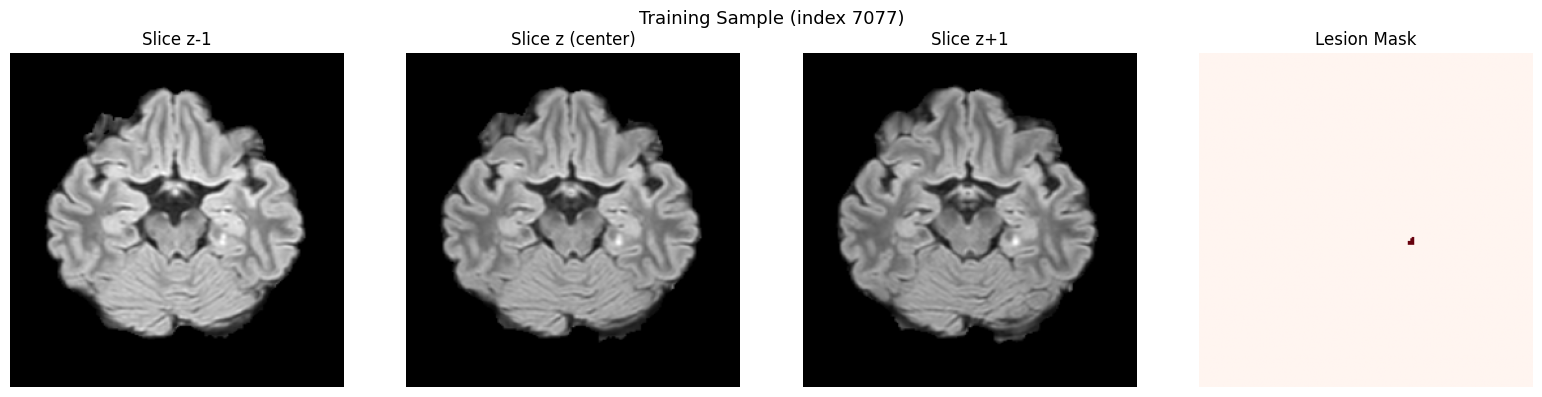

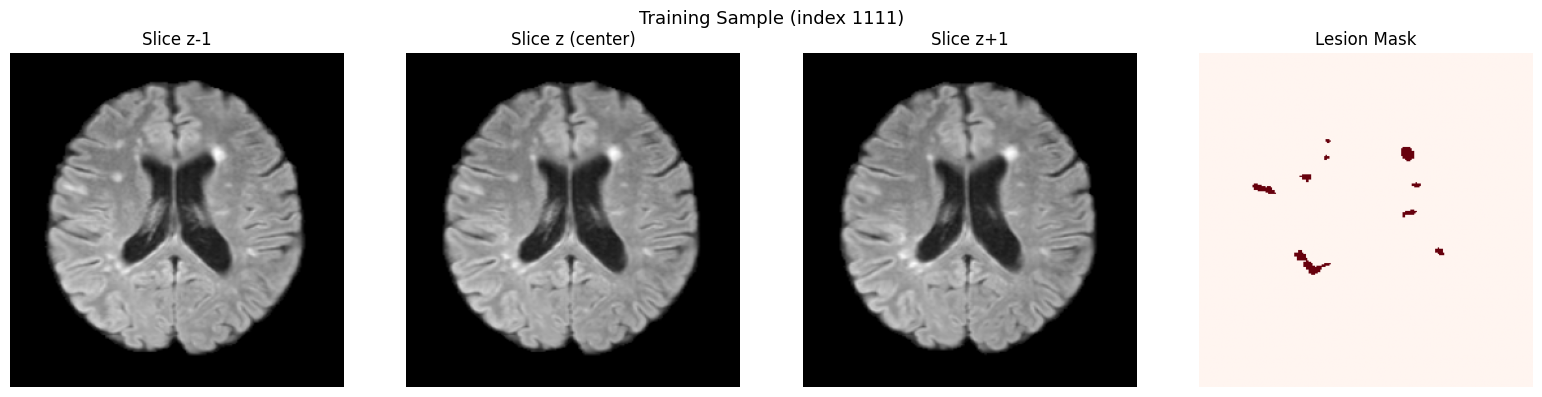

In [ ]:
# =============================================
# Data Loaders
# =============================================

BATCH_SIZE = 16

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True
)

print(f"Training samples: {len(train_dataset)}")
print(f"Training batches: {len(train_loader)}")

# --- Visualize a few training samples ---
def visualize_sample(dataset, idx):
    """Show the 3 input slices and the target mask."""
    x, mask = dataset[idx]
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))

    titles = ["Slice z-1", "Slice z (center)", "Slice z+1", "Lesion Mask"]
    for i in range(3):
        axes[i].imshow(x[i].numpy().T, cmap="gray", origin="lower")
        axes[i].set_title(titles[i])
        axes[i].axis("off")

    axes[3].imshow(mask[0].numpy().T, cmap="Reds", origin="lower")
    axes[3].set_title(titles[3])
    axes[3].axis("off")

    plt.suptitle(f"Training Sample (index {idx})", fontsize=13)
    plt.tight_layout()
    plt.show()

# Show 2 random training samples
for idx in np.random.choice(len(train_dataset), 2, replace=False):
    visualize_sample(train_dataset, idx)

## Training

I use a straightforward training loop with:

- **Loss function:** Binary Cross-Entropy (BCE) — standard for binary segmentation.
- **Optimizer:** Adam with learning rate 1×10⁻⁴.
- **Epochs:** 20 — enough for convergence, keeps total training time reasonable on Colab.
- **Batch size:** 16 — fits in Colab T4 GPU memory and reduces number of steps per epoch.
- **Validation:** I use an 80/20 split of the training data to monitor overfitting.

I also track the **Dice score** during training to monitor segmentation quality.

In [ ]:
# =============================================
# Metrics
# =============================================

def compute_dice(pred, target, threshold=0.5):
    """Compute Dice score for binary segmentation."""
    pred_binary = (pred > threshold).float()
    intersection = (pred_binary * target).sum()
    dice = (2.0 * intersection) / (pred_binary.sum() + target.sum() + 1e-8)
    return dice.item()


def compute_iou(pred, target, threshold=0.5):
    """Compute IoU (Jaccard) for binary segmentation."""
    pred_binary = (pred > threshold).float()
    intersection = (pred_binary * target).sum()
    union = pred_binary.sum() + target.sum() - intersection
    iou = intersection / (union + 1e-8)
    return iou.item()


# =============================================
# Training and Validation Functions
# =============================================

def train_one_epoch(model, loader, optimizer, criterion):
    """Train for one epoch. Returns average loss and Dice."""
    model.train()
    total_loss = 0.0
    total_dice = 0.0

    for images, masks in tqdm(loader, desc="Training", leave=False):
        images = images.to(device)   # (B, 3, H, W)
        masks = masks.to(device)     # (B, 1, H, W)

        optimizer.zero_grad()
        predictions = model(images)  # (B, 1, H, W)
        loss = criterion(predictions, masks)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_dice += compute_dice(predictions.detach(), masks)

    n = len(loader)
    return total_loss / n, total_dice / n


def validate(model, loader, criterion):
    """Validate. Returns average loss and Dice."""
    model.eval()
    total_loss = 0.0
    total_dice = 0.0

    with torch.no_grad():
        for images, masks in tqdm(loader, desc="Validation", leave=False):
            images = images.to(device)
            masks = masks.to(device)
            predictions = model(images)
            loss = criterion(predictions, masks)

            total_loss += loss.item()
            total_dice += compute_dice(predictions, masks)

    n = len(loader)
    return total_loss / n, total_dice / n

In [ ]:
# =============================================
# Data Augmentation (training only)
# =============================================
# Wraps a Subset and applies random augmentations on-the-fly.
# Spatial transforms are applied identically to input and mask.
# Intensity transforms are applied only to the input.

import scipy.ndimage

class AugmentedDataset(Dataset):
    """Wrapper that applies random augmentations to a dataset/subset."""

    def __init__(self, subset, p=0.5):
        self.subset = subset
        self.p = p  # probability of each augmentation being applied

    def __len__(self):
        return len(self.subset)

    def __getitem__(self, idx):
        x, y = self.subset[idx]  # x: (C, H, W), y: (1, H, W)
        x = x.numpy()
        y = y.numpy()

        # --- Spatial augmentations (applied to both x and y) ---

        # Random horizontal flip
        if np.random.random() < self.p:
            x = x[:, ::-1, :].copy()
            y = y[:, ::-1, :].copy()

        # Random vertical flip
        if np.random.random() < self.p:
            x = x[:, :, ::-1].copy()
            y = y[:, :, ::-1].copy()

        # Random 90-degree rotation (0, 90, 180, or 270)
        k = np.random.randint(0, 4)
        if k > 0:
            x = np.rot90(x, k, axes=(1, 2)).copy()
            y = np.rot90(y, k, axes=(1, 2)).copy()

        # Random small rotation (-15 to +15 degrees)
        if np.random.random() < self.p:
            angle = np.random.uniform(-15, 15)
            for c in range(x.shape[0]):
                x[c] = scipy.ndimage.rotate(x[c], angle, reshape=False, order=1, mode='nearest')
            y[0] = scipy.ndimage.rotate(y[0], angle, reshape=False, order=0, mode='nearest')

        # --- Intensity augmentations (input only) ---

        # Random brightness shift
        if np.random.random() < self.p:
            shift = np.random.uniform(-0.1, 0.1)
            x = np.clip(x + shift, 0, 1)

        # Random contrast scaling
        if np.random.random() < self.p:
            factor = np.random.uniform(0.8, 1.2)
            mean = x.mean()
            x = np.clip((x - mean) * factor + mean, 0, 1)

        # Random Gaussian noise
        if np.random.random() < self.p:
            noise = np.random.normal(0, 0.02, x.shape).astype(np.float32)
            x = np.clip(x + noise, 0, 1)

        return torch.from_numpy(x.astype(np.float32)), torch.from_numpy(y.astype(np.float32))


print("Augmentation pipeline defined:")
print("  Spatial:   horizontal flip, vertical flip, 90° rotation, small rotation (±15°)")
print("  Intensity: brightness shift, contrast scaling, Gaussian noise")
print("  Each augmentation applied with p=0.5 (training only)")

Augmentation pipeline defined:
  Spatial:   horizontal flip, vertical flip, 90° rotation, small rotation (±15°)
  Intensity: brightness shift, contrast scaling, Gaussian noise
  Each augmentation applied with p=0.5 (training only)


In [ ]:
# =============================================
# Train/Validation Split — BY PATIENT (no data leakage)
# =============================================
# Split at the PATIENT level, then partition slice indices accordingly.
# Augmentation is applied ONLY to the training set via AugmentedDataset.

from sklearn.model_selection import train_test_split

# Get unique patient IDs from training samples
patient_ids = sorted(set(s["patient"] for s in train_samples))
print(f"Total training patients: {len(patient_ids)}")

# Split patients into train/val (80/20)
val_ratio = 0.2
train_patients, val_patients = train_test_split(
    patient_ids, test_size=val_ratio, random_state=SEED
)
train_patient_set = set(train_patients)
val_patient_set = set(val_patients)

print(f"Train patients ({len(train_patients)}): {sorted(train_patients)}")
print(f"Val patients   ({len(val_patients)}):  {sorted(val_patients)}")

# Split slice indices by patient (data is already loaded in train_dataset)
train_indices = []
val_indices = []

for i, (vol_idx, z) in enumerate(train_dataset.slice_index):
    patient_id = train_dataset.samples[vol_idx]["patient"]
    if patient_id in val_patient_set:
        val_indices.append(i)
    else:
        train_indices.append(i)

# Wrap training subset with augmentation, validation stays clean
train_subset = AugmentedDataset(
    torch.utils.data.Subset(train_dataset, train_indices), p=0.5
)
val_subset = torch.utils.data.Subset(train_dataset, val_indices)

train_loader = DataLoader(
    train_subset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True
)
val_loader = DataLoader(
    val_subset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True
)

print(f"\nTraining samples (slices): {len(train_subset)} (with augmentation)")
print(f"Validation samples (slices): {len(val_subset)} (no augmentation)")


# =============================================
# Training Loop
# =============================================

NUM_EPOCHS = 20
LEARNING_RATE = 1e-4

criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

history = {"train_loss": [], "train_dice": [], "val_loss": [], "val_dice": []}
best_val_dice = 0.0

print(f"\nStarting training for {NUM_EPOCHS} epochs...")
print("=" * 55)

for epoch in range(NUM_EPOCHS):
    print(f"\nEpoch {epoch + 1}/{NUM_EPOCHS}")

    # Train
    train_loss, train_dice = train_one_epoch(model, train_loader, optimizer, criterion)

    # Validate
    val_loss, val_dice = validate(model, val_loader, criterion)

    # Record history
    history["train_loss"].append(train_loss)
    history["train_dice"].append(train_dice)
    history["val_loss"].append(val_loss)
    history["val_dice"].append(val_dice)

    print(f"  Train Loss: {train_loss:.4f}  Train Dice: {train_dice:.4f}")
    print(f"  Val Loss:   {val_loss:.4f}  Val Dice:   {val_dice:.4f}")

    # Save best model
    if val_dice > best_val_dice:
        best_val_dice = val_dice
        torch.save(model.state_dict(), OUTPUT_DIR / "unet_25d_best.pth")
        print(f"  >> Saved best model (Val Dice: {best_val_dice:.4f})")

print("\n" + "=" * 55)
print(f"Training complete! Best Val Dice: {best_val_dice:.4f}")

Total training patients: 53
Train patients (42): ['P1', 'P10', 'P11', 'P13', 'P15', 'P16', 'P17', 'P18', 'P19', 'P2', 'P22', 'P23', 'P24', 'P26', 'P28', 'P29', 'P3', 'P30', 'P31', 'P32', 'P33', 'P34', 'P35', 'P36', 'P37', 'P38', 'P4', 'P40', 'P41', 'P42', 'P43', 'P44', 'P45', 'P46', 'P48', 'P5', 'P50', 'P51', 'P53', 'P6', 'P8', 'P9']
Val patients   (11):  ['P12', 'P14', 'P20', 'P21', 'P25', 'P27', 'P39', 'P47', 'P49', 'P52', 'P7']

Training samples (slices): 6234 (with augmentation)
Validation samples (slices): 2076 (no augmentation)

Starting training for 20 epochs...

Epoch 1/20


  Train Loss: 0.4117  Train Dice: 0.0058
  Val Loss:   0.3251  Val Dice:   0.0002
  >> Saved best model (Val Dice: 0.0002)

Epoch 2/20


  Train Loss: 0.2557  Train Dice: 0.0690
  Val Loss:   0.2104  Val Dice:   0.0976
  >> Saved best model (Val Dice: 0.0976)

Epoch 3/20


  Train Loss: 0.1718  Train Dice: 0.1266
  Val Loss:   0.1478  Val Dice:   0.1260
  >> Saved best model (Val Dice: 0.1260)

Epoch 4/20


  Train Loss: 0.1176  Train Dice: 0.2918
  Val Loss:   0.1025  Val Dice:   0.4012
  >> Saved best model (Val Dice: 0.4012)

Epoch 5/20


...

  Train Loss: 0.0067  Train Dice: 0.7479
  Val Loss:   0.0088  Val Dice:   0.6117

Epoch 17/20


  Train Loss: 0.0060  Train Dice: 0.7413
  Val Loss:   0.0076  Val Dice:   0.6562
  >> Saved best model (Val Dice: 0.6562)

Epoch 18/20


  Train Loss: 0.0054  Train Dice: 0.7441
  Val Loss:   0.0073  Val Dice:   0.6093

Epoch 19/20


  Train Loss: 0.0048  Train Dice: 0.7514
  Val Loss:   0.0072  Val Dice:   0.6454

Epoch 20/20


  Train Loss: 0.0044  Train Dice: 0.7547
  Val Loss:   0.0065  Val Dice:   0.6499

Training complete! Best Val Dice: 0.6562


Freed training data from RAM.


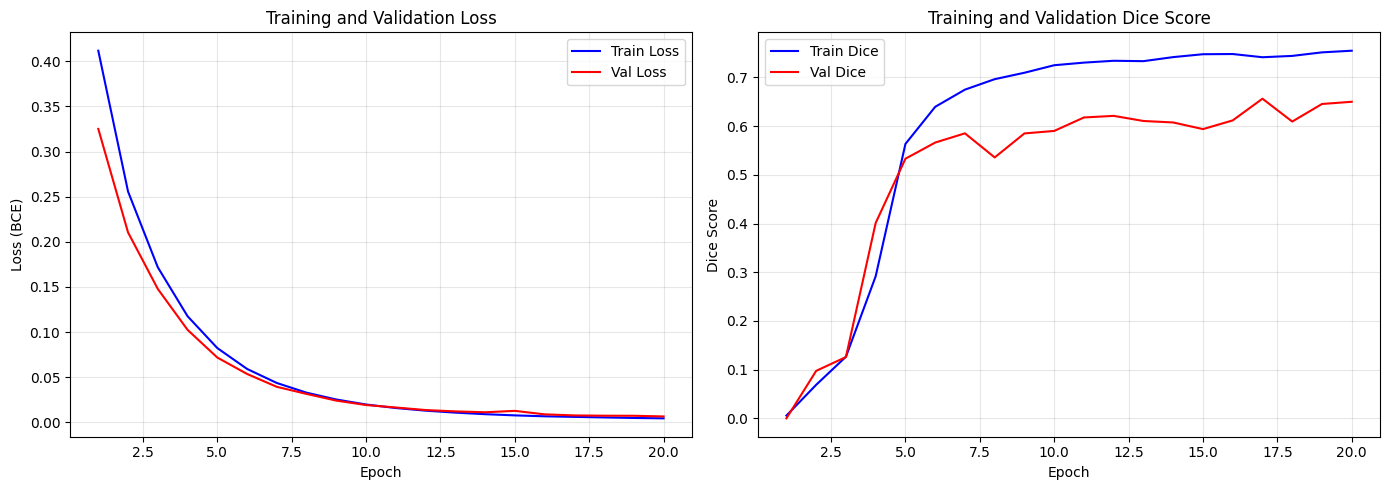

Best Val Dice: 0.6562 at epoch 17


In [ ]:
# =============================================
# Free training data from RAM before plotting
# =============================================
for _v in ['train_dataset', 'train_subset', 'val_subset', 'train_loader', 'val_loader']:
    if _v in globals():
        del globals()[_v]
import gc; gc.collect()
torch.cuda.empty_cache()
print("Freed training data from RAM.")

# =============================================
# Plot Training History
# =============================================

epochs = range(1, len(history["train_loss"]) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss
ax1.plot(epochs, history["train_loss"], "b-", label="Train Loss")
ax1.plot(epochs, history["val_loss"], "r-", label="Val Loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss (BCE)")
ax1.set_title("Training and Validation Loss")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Dice
ax2.plot(epochs, history["train_dice"], "b-", label="Train Dice")
ax2.plot(epochs, history["val_dice"], "r-", label="Val Dice")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Dice Score")
ax2.set_title("Training and Validation Dice Score")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "training_history_25d.png", dpi=150)
plt.show()

best_epoch = history["val_dice"].index(max(history["val_dice"])) + 1
print(f"Best Val Dice: {max(history['val_dice']):.4f} at epoch {best_epoch}")

## Evaluation on the Test Set

I evaluate the trained model on the **entire test set**, which consists of completely
separate patients that were never seen during training. This is the standard evaluation
protocol from the MSLesSeg dataset.

I compute:
- **Dice Score**: Measures overlap between prediction and ground truth.
  $$\text{Dice} = \frac{2 \cdot |P \cap G|}{|P| + |G|}$$
- **IoU** (Intersection over Union): Another overlap metric, always ≤ Dice.
  $$\text{IoU} = \frac{|P \cap G|}{|P \cup G|}$$
- **Precision and Recall**: How many predicted lesion pixels are correct, and how many
  true lesion pixels are found.

Metrics are computed **per patient** and then averaged, so that each patient contributes
equally regardless of the number of slices.

In [ ]:
# =============================================
# Load Best Model and Evaluate on Test Set
# =============================================

# Now load test data into RAM
print("Preloading test data...")
test_dataset = MSLesion25D_Dataset(
    test_samples, num_adjacent=NUM_ADJACENT_SLICES, target_size=TARGET_SIZE,
    bg_keep_ratio=0.15,
)

test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True
)

# Load best model weights
model.load_state_dict(torch.load(OUTPUT_DIR / "unet_25d_best.pth"))
model.eval()
print("\nLoaded best model from checkpoint.")

# --- Overall test evaluation ---
print("\nEvaluating on the entire test set...")
test_loss, test_dice = validate(model, test_loader, criterion)
print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test Dice: {test_dice:.4f}")

# --- Per-patient evaluation ---
print("\nComputing per-patient metrics...")

# Build a mapping: which indices in test_dataset belong to each patient
patient_indices = {}
for i, (vol_idx, z) in enumerate(test_dataset.slice_index):
    patient_id = test_dataset.samples[vol_idx]["patient"]
    if patient_id not in patient_indices:
        patient_indices[patient_id] = []
    patient_indices[patient_id].append(i)

# Compute metrics for each patient
patient_results = {}

for patient_id, indices in sorted(patient_indices.items()):
    all_preds = []
    all_masks = []

    for idx in indices:
        x, mask = test_dataset[idx]
        x = x.unsqueeze(0).to(device)

        with torch.no_grad():
            pred = model(x)

        all_preds.append(pred.cpu())
        all_masks.append(mask.unsqueeze(0))

    all_preds = torch.cat(all_preds, dim=0)
    all_masks = torch.cat(all_masks, dim=0)

    # Compute metrics for this patient
    pred_binary = (all_preds > 0.5).float()
    tp = (pred_binary * all_masks).sum()
    fp = (pred_binary * (1 - all_masks)).sum()
    fn = ((1 - pred_binary) * all_masks).sum()

    dice = (2 * tp / (2 * tp + fp + fn + 1e-8)).item()
    iou = (tp / (tp + fp + fn + 1e-8)).item()
    precision = (tp / (tp + fp + 1e-8)).item()
    recall = (tp / (tp + fn + 1e-8)).item()

    patient_results[patient_id] = {
        "dice": dice, "iou": iou,
        "precision": precision, "recall": recall,
        "num_slices": len(indices),
    }

# --- Print results table ---
print("\n" + "=" * 75)
print(f"{'Patient':<12} {'Dice':<10} {'IoU':<10} {'Precision':<12} {'Recall':<10} {'Slices':<8}")
print("=" * 75)

for pid, m in sorted(patient_results.items()):
    print(f"{pid:<12} {m['dice']:<10.4f} {m['iou']:<10.4f} "
          f"{m['precision']:<12.4f} {m['recall']:<10.4f} {m['num_slices']:<8}")

print("-" * 75)

# Averages across all patients
avg_dice = np.mean([m["dice"] for m in patient_results.values()])
avg_iou = np.mean([m["iou"] for m in patient_results.values()])
avg_prec = np.mean([m["precision"] for m in patient_results.values()])
avg_rec = np.mean([m["recall"] for m in patient_results.values()])

print(f"{'MEAN':<12} {avg_dice:<10.4f} {avg_iou:<10.4f} "
      f"{avg_prec:<12.4f} {avg_rec:<10.4f}")
print("=" * 75)

Preloading test data...
Preloading 22 volumes into RAM (one-time cost)...


Loading: 100%|██████████| 22/22 [01:28<00:00,  4.04s/it]


Total 2.5D samples: 2091
  Slices with lesions: 1751
  Background slices:   340 (15% kept)

Loaded best model from checkpoint.

Evaluating on the entire test set...



Test Loss: 0.0066
Test Dice: 0.5845

Computing per-patient metrics...

Patient      Dice       IoU        Precision    Recall     Slices  
P54          0.7241     0.5675     0.5964       0.9212     65      
P55          0.6383     0.4687     0.7916       0.5347     106     
P56          0.7349     0.5809     0.9028       0.6196     54      
P57          0.7357     0.5820     0.8650       0.6401     135     
P58          0.6104     0.4393     0.6650       0.5641     109     
P59          0.4062     0.2549     0.3945       0.4186     66      
P60          0.6693     0.5030     0.6069       0.7461     115     
P61          0.6691     0.5027     0.5572       0.8371     88      
P62          0.6890     0.5255     0.8049       0.6023     102     
P63          0.7169     0.5588     0.6442       0.8081     81      
P64          0.7008     0.5395     0.6485       0.7624     100     
P65          0.7632     0.6170     0.7901       0.7380     124     
P66          0.7096     0.5499     0.6918   

## Visualizations

Below I show prediction examples from the test set and a bar chart of per-patient Dice
scores.

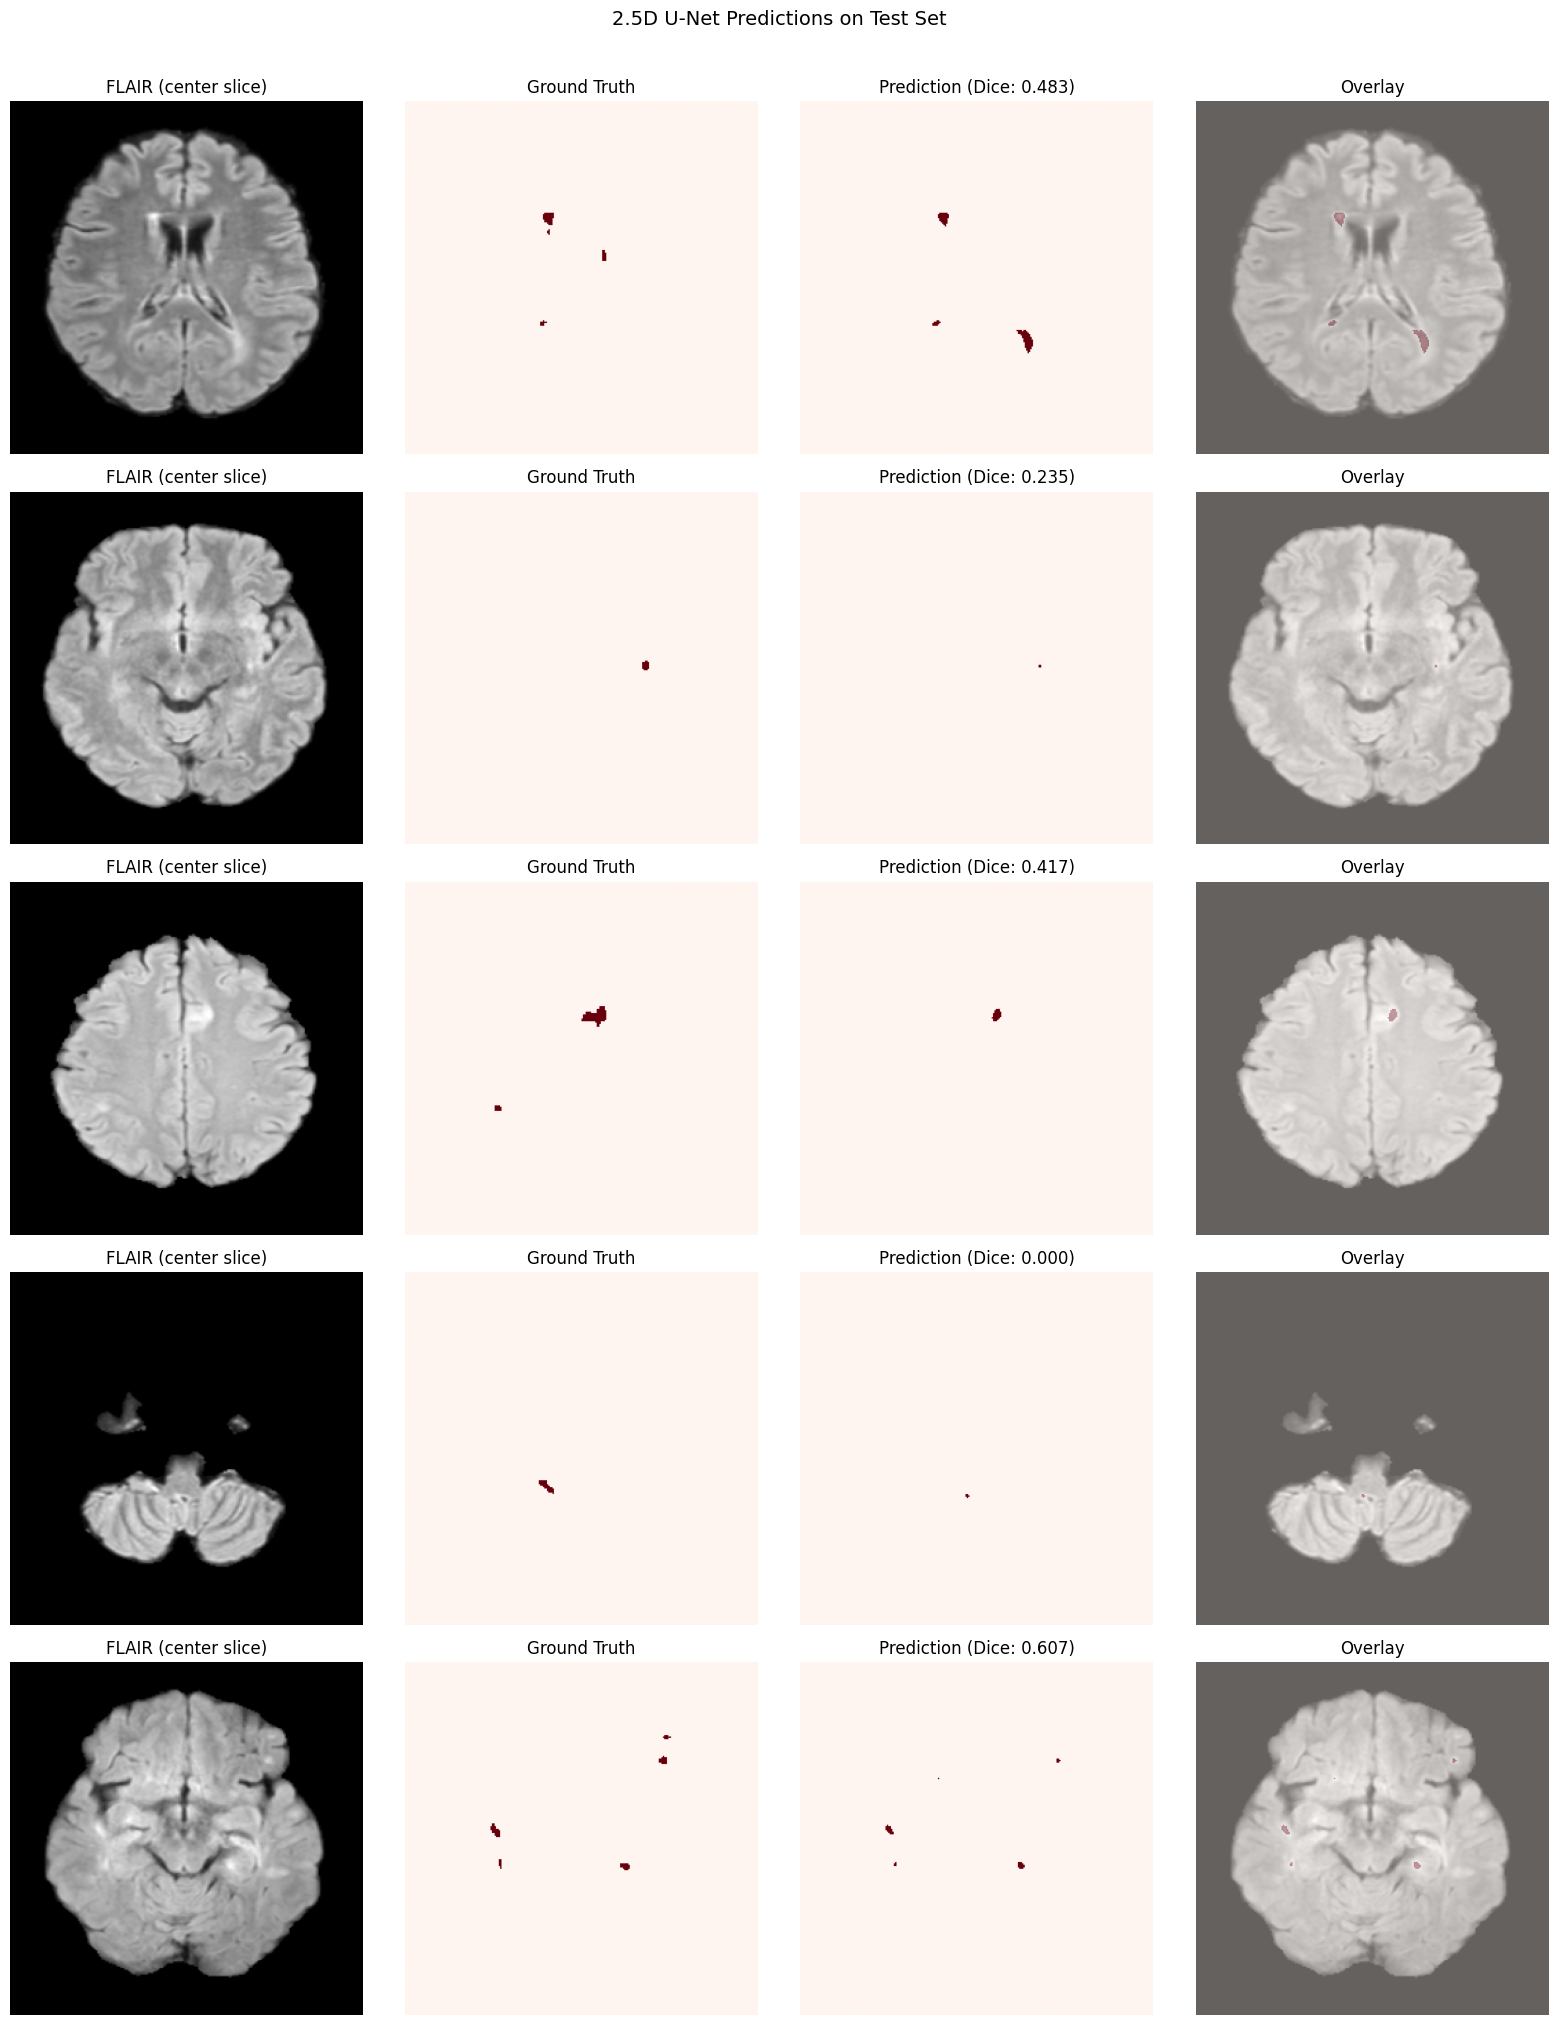

In [ ]:
# =============================================
# Visualize Predictions on Test Set
# =============================================

def visualize_test_predictions(model, dataset, num_samples=5):
    """Show FLAIR input, ground truth, and prediction side by side."""
    model.eval()

    # Pick random samples that have some lesion content
    indices = np.random.choice(len(dataset), min(num_samples * 3, len(dataset)), replace=False)
    selected = []
    for idx in indices:
        _, mask = dataset[idx]
        if mask.sum() > 0:
            selected.append(idx)
        if len(selected) >= num_samples:
            break

    fig, axes = plt.subplots(len(selected), 4, figsize=(16, 4 * len(selected)))
    if len(selected) == 1:
        axes = axes[np.newaxis, :]

    for i, idx in enumerate(selected):
        x, mask = dataset[idx]

        with torch.no_grad():
            pred = model(x.unsqueeze(0).to(device))
            pred_np = pred.squeeze().cpu().numpy()
            pred_binary = (pred_np > 0.5).astype(float)

        # Central FLAIR slice
        central = x[x.shape[0] // 2].numpy()
        dice = compute_dice(pred.cpu(), mask.unsqueeze(0))

        axes[i, 0].imshow(central.T, cmap="gray", origin="lower")
        axes[i, 0].set_title("FLAIR (center slice)")
        axes[i, 0].axis("off")

        axes[i, 1].imshow(mask[0].numpy().T, cmap="Reds", origin="lower")
        axes[i, 1].set_title("Ground Truth")
        axes[i, 1].axis("off")

        axes[i, 2].imshow(pred_binary.T, cmap="Reds", origin="lower")
        axes[i, 2].set_title(f"Prediction (Dice: {dice:.3f})")
        axes[i, 2].axis("off")

        # Overlay
        axes[i, 3].imshow(central.T, cmap="gray", origin="lower")
        axes[i, 3].imshow(pred_binary.T, cmap="Reds", alpha=0.4, origin="lower")
        axes[i, 3].set_title("Overlay")
        axes[i, 3].axis("off")

    plt.suptitle("2.5D U-Net Predictions on Test Set", fontsize=14, y=1.01)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "predictions_25d.png", dpi=150, bbox_inches="tight")
    plt.show()


visualize_test_predictions(model, test_dataset, num_samples=5)

## Save the Trained Model

I save the final model weights to Google Drive so I can reload them later.

In [ ]:
# Save final model
save_path = OUTPUT_DIR / "unet_25d_final.pth"
torch.save(model.state_dict(), save_path)
print(f"Model saved to: {save_path}")
print(f"File size: {os.path.getsize(save_path) / 1e6:.1f} MB")

# To reload later:
# model = UNet25D(in_channels=3, base_features=32).to(device)
# model.load_state_dict(torch.load(OUTPUT_DIR / "unet_25d_final.pth"))
# model.eval()

Model saved to: /content/drive/MyDrive/MSLesSeg/MSLesSeg Dataset/outputs/unet_25d_final.pth
File size: 31.1 MB


In [ ]:
# =============================================
# Final Summary
# =============================================

print("=" * 65)
print("FINAL SUMMARY - 2.5D U-Net for MS Lesion Segmentation")
print("=" * 65)

print(f"\nDataset: MSLesSeg ({len(train_samples)} train + {len(test_samples)} test scans)")
print(f"Model: 2.5D U-Net ({total_params:,} parameters)")
print(f"Input: {NUM_ADJACENT_SLICES} adjacent FLAIR slices at {TARGET_SIZE}")

print(f"\nVALIDATION:")
print(f"  Best Val Dice: {max(history['val_dice']):.4f} (epoch {best_epoch})")

print(f"\nTEST SET (per-patient average):")
print(f"  Dice Score: {avg_dice:.4f}")
print(f"  IoU:        {avg_iou:.4f}")
print(f"  Precision:  {avg_prec:.4f}")
print(f"  Recall:     {avg_rec:.4f}")

gap = abs(max(history["val_dice"]) - avg_dice)
print(f"\nGeneralization gap (|Best Val - Test| Dice): {gap:.4f}")
if gap < 0.05:
    print("  -> Good generalization")
elif gap < 0.10:
    print("  -> Moderate generalization")
else:
    print("  -> Possible overfitting")

print("\n" + "=" * 65)

FINAL SUMMARY - 2.5D U-Net for MS Lesion Segmentation

Dataset: MSLesSeg (93 train + 22 test scans)
Model: 2.5D U-Net (7,765,985 parameters)
Input: 3 adjacent FLAIR slices at (256, 256)

VALIDATION:
  Best Val Dice: 0.6562 (epoch 17)

TEST SET (per-patient average):
  Dice Score: 0.6657
  IoU:        0.5082
  Precision:  0.6982
  Recall:     0.6725

Generalization gap (|Best Val - Test| Dice): 0.0095
  -> Good generalization



## Conclusion

In this project, I implemented a **2.5D U-Net** for automatic segmentation of Multiple
Sclerosis lesions from FLAIR MRI scans, using the MSLesSeg dataset.

**Summary of my approach:**

- **Architecture:** A lightweight 2.5D U-Net (~10M parameters) that takes 3 adjacent
  FLAIR slices as input and outputs a binary lesion mask for the central slice. This
  captures inter-slice context without the prohibitive memory cost of full 3D convolutions.
- **Data handling:** All lesions are included regardless of size — no filtering. The
  training and test sets consist of entirely different patients as provided by the dataset.
- **Training:** BCE loss, Adam optimizer (lr=1e-4), 20 epochs, with train/val split
  for monitoring overfitting. Volumes are preloaded into RAM for fast training.
- **Evaluation:** Dice, IoU, Precision, and Recall computed per patient on the full
  test set.

**Comparison to the 2D baseline:**
The main advantage of 2.5D over pure 2D is that the model can leverage context from
neighboring slices. This is particularly helpful for MS lesions that span multiple
slices — the model can see the lesion "growing" or "shrinking" in adjacent slices,
leading to more consistent segmentation.

**Limitations and possible improvements:**
- Using more adjacent slices (e.g., 5 instead of 3) could capture more context.
- Data augmentation (flips, rotations, intensity perturbations) could reduce overfitting.
- A learning rate scheduler could improve convergence.